# LSTM and TCN: unrestricted 72 h versus manual 42 h

This notebook implements the paper's sequence models on one matched, leakage-safe forecasting task: the next **72 hours / 288 quarter-hour values** at Indusii.

- **Unrestricted 72 h:** 288 rows × all five sensor values; the network can infer lag structure.
- **Manual 42 h:** a 168-row sequence of the paper's four engineered variables (current target, one- and two-hour target change, and Terneuzen shifted by 42 h). The final row is exactly the paper's compact four-feature ablation; extending it as a sequence lets LSTM and TCN operate meaningfully without changing the manual lag hypothesis.
- **Chronology:** January--July train, August validation/calibration, September test.
- **Baseline:** persistence at every lead; models learn only the future change from the most recent target. Skill is compared at 4, 8, 16, 24, and 48 hours as well as over the complete trajectory.

The architecture cells document the improvements made after inspecting `LSTM_salinity_simple_fuseki.ipynb`, `TCN_salinity_simple_fuseki.ipynb`, `TCN_salinity_simple_fuseki_v2.ipynb`, and `tcn_salinity.py`.

In [1]:
from pathlib import Path
import os, sys, time

ROOT = Path.cwd().resolve()
if not (ROOT / "lag_analytics_workspace").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib-cache"))
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from time_series_analysis.paper_experiment_utils import (
    EVALUATION_HOURS,
    FORECAST_HOURS,
    FORECAST_STEPS,
    build_neural_datasets,
    evaluation_rows,
    load_prepared_observations,
    split_shape_table,
    validation_calibration,
)

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.threading.set_intra_op_parallelism_threads(min(8, os.cpu_count() or 1))
    tf.config.threading.set_inter_op_parallelism_threads(2)
except RuntimeError:
    pass
print("TensorFlow", tf.__version__, "devices:", tf.config.list_physical_devices())

TensorFlow 2.21.0 devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 1. Matched sequence datasets

In [2]:
data, coverage, unit_report = load_prepared_observations()
datasets = build_neural_datasets(data)
display(coverage)
display(split_shape_table(datasets))

,first observation,last observation,missing after preparation,minimum mS/cm,maximum mS/cm
sensor,,,,,
Terneuzen,2025-01-01 00:00:00+00:00,2026-03-23 15:45:00+00:00,372,0.108207,2.339817
Westdorpe,2025-01-01 00:00:00+00:00,2025-10-07 07:30:00+00:00,257,0.107912,3.997718
Gent - far,2025-01-01 00:00:00+00:00,2026-03-23 12:00:00+00:00,254,0.055390,1.882214
Gent - near,2025-01-01 00:00:00+00:00,2025-12-18 23:00:00+00:00,253,0.068467,1.792810
Indusii,2025-01-01 00:00:00+00:00,2025-12-31 23:45:00+00:00,962,0.000018,1.945475


,Representation,Split,X shape,y shape,First forecast,Last forecast
0,unrestricted_72h,train,"(3740, 288, 5)","(3740, 288)",2025-01-07 13:45:00+00:00,2025-07-31 23:45:00+00:00
1,unrestricted_72h,validation,"(2098, 288, 5)","(2098, 288)",2025-08-10 03:30:00+00:00,2025-08-31 23:45:00+00:00
2,unrestricted_72h,test,"(2593, 288, 5)","(2593, 288)",2025-09-03 23:45:00+00:00,2025-09-30 23:45:00+00:00
3,manual_42h,train,"(3740, 168, 4)","(3740, 288)",2025-01-07 13:45:00+00:00,2025-07-31 23:45:00+00:00
4,manual_42h,validation,"(2098, 168, 4)","(2098, 288)",2025-08-10 03:30:00+00:00,2025-08-31 23:45:00+00:00
5,manual_42h,test,"(2593, 168, 4)","(2593, 288)",2025-09-03 23:45:00+00:00,2025-09-30 23:45:00+00:00


## 2. Architecture review and revised definitions

The existing LSTM is well regularized but used a 32-unit dense layer despite the paper describing 64 units. The revised model restores 64 units and adds a latest-input skip connection, giving the residual head direct access to the present state.

The existing notebooks disagree on whether TCN predicts one endpoint or the complete horizon. The revised TCN always emits 16 values. Its six dilation levels `(1, 2, 4, 8, 16, 32)`, two kernel-5 convolutions per block, have a **505-step receptive field**, covering both the 288-step unrestricted input and the 168-step manual sequence. Residual projections, layer normalization, spatial dropout, light L2 regularization, gradient clipping, Huber loss, and validation-restored early stopping improve stability.

In [3]:
L2 = 1e-5

def build_lstm(input_shape):
    inputs = keras.Input(shape=input_shape, name="history")
    x = layers.LSTM(64, return_sequences=True, kernel_regularizer=regularizers.l2(L2))(inputs)
    x = layers.Dropout(0.10)(x)
    x = layers.LSTM(32, kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.LayerNormalization()(x)
    latest = layers.Lambda(lambda z: z[:, -1, :], name="latest_input")(inputs)
    x = layers.Concatenate()([x, latest])
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.Dropout(0.10)(x)
    outputs = layers.Dense(FORECAST_STEPS, kernel_initializer="zeros", name="delta_forecast")(x)
    return keras.Model(inputs, outputs, name="LSTM_residual_forecaster")


def residual_tcn_block(x, filters, kernel_size, dilation):
    shortcut = x
    for conv_number in range(2):
        x = layers.Conv1D(
            filters, kernel_size, padding="causal", dilation_rate=dilation,
            kernel_regularizer=regularizers.l2(L2),
            name=f"d{dilation}_conv{conv_number + 1}",
        )(x)
        x = layers.LayerNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.SpatialDropout1D(0.10)(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding="same")(shortcut)
    return layers.Activation("relu")(layers.Add()([x, shortcut]))


def build_tcn(input_shape):
    inputs = keras.Input(shape=input_shape, name="history")
    x = inputs
    for dilation in (1, 2, 4, 8, 16, 32):
        x = residual_tcn_block(x, filters=24, kernel_size=5, dilation=dilation)
    x = layers.Lambda(lambda z: z[:, -1, :], name="causal_last_state")(x)
    latest = layers.Lambda(lambda z: z[:, -1, :], name="latest_input")(inputs)
    x = layers.Concatenate()([x, latest])
    x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(L2))(x)
    x = layers.Dropout(0.10)(x)
    outputs = layers.Dense(FORECAST_STEPS, kernel_initializer="zeros", name="delta_forecast")(x)
    return keras.Model(inputs, outputs, name="TCN_residual_forecaster")


def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0),
        loss=keras.losses.Huber(delta=1.0),
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


for builder in (build_lstm, build_tcn):
    preview = builder((288, 5))
    print(f"{preview.name}: {preview.count_params():,} parameters")
print("TCN receptive field:", 1 + 2 * (5 - 1) * sum((1, 2, 4, 8, 16, 32)), "steps")
tf.keras.backend.clear_session()


LSTM_residual_forecaster: 51,552 parameters
TCN_residual_forecaster: 53,928 parameters
TCN receptive field: 505 steps


## 3. Train with August-only model selection

Training targets are standardized per horizon using January--July only. Batch shuffling changes the order of complete windows, never the order inside a sequence. Early stopping restores the best August weights. As in the classical notebook, August can only shrink each predicted residual toward persistence.

In [4]:
builders = {"LSTM": build_lstm, "TCN": build_tcn}
epochs = {"LSTM": 40, "TCN": 45}
batch_sizes = {"LSTM": 128, "TCN": 256}

all_rows, all_horizons, fit_rows = [], [], []
predictions, validation_predictions, test_delta_predictions, histories = {}, {}, {}, {}

for representation, dataset in datasets.items():
    train, validation, test = (dataset.splits[name] for name in ("train", "validation", "test"))
    scale = dataset.target_scale
    for model_name, builder in builders.items():
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEED)
        model = compile_model(builder(train.X.shape[1:]))
        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_loss", patience=7, min_delta=1e-4,
                restore_best_weights=True, verbose=1,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss", factor=0.5, patience=3,
                min_lr=1e-5, verbose=1,
            ),
        ]
        print(f"\nTraining {model_name} on {representation}: {model.count_params():,} parameters")
        started = time.perf_counter()
        history = model.fit(
            train.X, train.y_delta / scale,
            validation_data=(validation.X, validation.y_delta / scale),
            epochs=epochs[model_name], batch_size=batch_sizes[model_name],
            shuffle=True, callbacks=callbacks, verbose=2,
        )
        elapsed = time.perf_counter() - started

        validation_raw = model.predict(validation.X, batch_size=512, verbose=0) * scale
        weights = validation_calibration(validation_raw, validation.y_delta)
        validation_calibrated = validation_raw * weights
        validation_persistence_rmse = float(np.sqrt(np.mean(validation.y_delta ** 2)))
        validation_rmse = float(np.sqrt(np.mean((validation_calibrated - validation.y_delta) ** 2)))

        test_raw = model.predict(test.X, batch_size=512, verbose=0) * scale
        test_calibrated = test_raw * weights
        rows, horizon, prediction = evaluation_rows(
            model_name, representation, test, test_calibrated
        )
        all_rows.extend(rows)
        all_horizons.append(horizon)
        predictions[(model_name, representation)] = prediction
        validation_predictions[(model_name, representation)] = validation_calibrated
        test_delta_predictions[(model_name, representation)] = test_calibrated
        histories[(model_name, representation)] = history.history
        fit_rows.append({
            "Model": model_name, "Representation": representation,
            "Parameters": model.count_params(), "Epochs": len(history.history["loss"]),
            "Fit seconds": elapsed, "Validation RMSE": validation_rmse,
            "Validation persistence RMSE": validation_persistence_rmse,
            "Validation RMSE skill": 1 - validation_rmse / validation_persistence_rmse,
            "Mean calibration weight": float(weights.mean()),
        })
        print(f"Completed in {elapsed:.1f}s; validation skill {fit_rows[-1]['Validation RMSE skill']:.3f}")

fit_summary = pd.DataFrame(fit_rows).sort_values("Validation RMSE")
results = pd.DataFrame(all_rows)
horizon_results = pd.concat(all_horizons, ignore_index=True)
display(fit_summary.round({
    "Fit seconds": 1, "Validation RMSE": 5,
    "Validation persistence RMSE": 5, "Validation RMSE skill": 3,
    "Mean calibration weight": 3,
}))


Training LSTM on unrestricted_72h: 51,552 parameters
Epoch 1/40
30/30 - 8s - 264ms/step - loss: 0.2561 - mae: 0.4892 - val_loss: 1.7519 - val_mae: 2.1102 - learning_rate: 3.0000e-04
Epoch 2/40
30/30 - 5s - 176ms/step - loss: 0.2468 - mae: 0.4740 - val_loss: 1.7808 - val_mae: 2.1580 - learning_rate: 3.0000e-04
Epoch 3/40
30/30 - 5s - 171ms/step - loss: 0.2369 - mae: 0.4615 - val_loss: 1.7884 - val_mae: 2.1696 - learning_rate: 3.0000e-04
Epoch 4/40

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
30/30 - 5s - 169ms/step - loss: 0.2299 - mae: 0.4540 - val_loss: 1.7902 - val_mae: 2.1740 - learning_rate: 3.0000e-04
Epoch 5/40
30/30 - 5s - 172ms/step - loss: 0.2246 - mae: 0.4489 - val_loss: 1.7955 - val_mae: 2.1822 - learning_rate: 1.5000e-04
Epoch 6/40
30/30 - 5s - 172ms/step - loss: 0.2212 - mae: 0.4442 - val_loss: 1.7963 - val_mae: 2.1843 - learning_rate: 1.5000e-04
Epoch 7/40

Epoch 7: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.
30/30 -

,Model,Representation,Parameters,Epochs,Fit seconds,Validation RMSE,Validation persistence RMSE,Validation RMSE skill,Mean calibration weight
3,TCN,manual_42h,53720,45,122.3,0.27250,0.31953,0.147,0.977
2,LSTM,manual_42h,51232,23,71.2,0.27708,0.31953,0.133,0.951
0,LSTM,unrestricted_72h,51552,8,44.2,0.31894,0.31953,0.002,1.000
1,TCN,unrestricted_72h,53928,8,43.2,0.31942,0.31953,0.000,1.000


## 4. Validation-prespecified ensemble

LSTM and TCN capture different dependencies, so their equal-weight average is a useful low-variance extension. The combination rule is fixed without looking at September.

In [5]:
for representation, dataset in datasets.items():
    validation, test = dataset.splits["validation"], dataset.splits["test"]
    validation_ensemble = 0.5 * (
        validation_predictions[("LSTM", representation)] +
        validation_predictions[("TCN", representation)]
    )
    test_ensemble = 0.5 * (
        test_delta_predictions[("LSTM", representation)] +
        test_delta_predictions[("TCN", representation)]
    )
    validation_persistence_rmse = float(np.sqrt(np.mean(validation.y_delta ** 2)))
    validation_rmse = float(np.sqrt(np.mean((validation_ensemble - validation.y_delta) ** 2)))
    rows, horizon, prediction = evaluation_rows(
        "LSTM+TCN ensemble", representation, test, test_ensemble
    )
    all_rows.extend(rows)
    all_horizons.append(horizon)
    predictions[("LSTM+TCN ensemble", representation)] = prediction
    fit_rows.append({
        "Model": "LSTM+TCN ensemble", "Representation": representation,
        "Parameters": np.nan, "Epochs": np.nan, "Fit seconds": 0.0,
        "Validation RMSE": validation_rmse,
        "Validation persistence RMSE": validation_persistence_rmse,
        "Validation RMSE skill": 1 - validation_rmse / validation_persistence_rmse,
        "Mean calibration weight": np.nan,
    })

fit_summary = pd.DataFrame(fit_rows).sort_values("Validation RMSE")
results = pd.DataFrame(all_rows)
horizon_results = pd.concat(all_horizons, ignore_index=True)
display(fit_summary[fit_summary["Model"] == "LSTM+TCN ensemble"].round({
    "Validation RMSE": 5, "Validation persistence RMSE": 5,
    "Validation RMSE skill": 3,
}))

,Model,Representation,Parameters,Epochs,Fit seconds,Validation RMSE,Validation persistence RMSE,Validation RMSE skill,Mean calibration weight
5,LSTM+TCN ensemble,manual_42h,NaN,NaN,0.0,0.27375,0.31953,0.143,NaN
4,LSTM+TCN ensemble,unrestricted_72h,NaN,NaN,0.0,0.31918,0.31953,0.001,NaN


## 5. Held-out September results

In [6]:
summary = results.pivot_table(
    index=["Model", "Representation"], columns="Scope",
    values=["RMSE", "R2", "RMSE skill"]
).sort_values(("RMSE", "all horizons"))
display(summary.round(4))

checkpoint_scopes = [f"{hours}-hour mark" for hours in EVALUATION_HOURS]
checkpoint_skill = (
    results[results["Scope"].isin(checkpoint_scopes)]
    .pivot(index=["Model", "Representation"], columns="Scope", values="RMSE skill")
    .reindex(columns=checkpoint_scopes)
)
display(checkpoint_skill.round(4))

R2                           \
Scope                              16-hour mark 24-hour mark 4-hour mark   
Model             Representation                                           
TCN               manual_42h            -0.0053       0.0576      0.2469   
LSTM+TCN ensemble manual_42h            -0.0466       0.0109      0.2183   
LSTM              manual_42h            -0.1047      -0.0527      0.1773   
                  unrestricted_72h      -0.3972      -0.3363      0.0338   
LSTM+TCN ensemble unrestricted_72h      -0.4002      -0.3403      0.0325   
TCN               unrestricted_72h      -0.4032      -0.3445      0.0311   

                                                                          \
Scope                              48-hour mark 8-hour mark all horizons   
Model             Representation                                           
TCN               manual_42h            -0.0399      0.1699       0.0134   
LSTM+TCN ensemble manual_42h            -0.0843      0.1343      -0.0213   
LSTM              manual_42h            -0.1488      0.0866      -0.0729   
                  unrestricted_72h      -0.4945     -0.1114      -0.3985   
LSTM+TCN ensemble unrestricted_72h      -0.5011     -0.1131      -0.4036   
TCN               unrestricted_72h      -0.5079     -0.1149      -0.4089   

                                                               RMSE  \
Scope                              largest 10% changes 16-hour mark   
Model             Representation                                      
TCN               manual_42h                   -0.8466       0.2881   
LSTM+TCN ensemble manual_42h                   -0.9026       0.2939   
LSTM              manual_42h                   -0.9706       0.3020   
                  unrestricted_72h             -1.9656       0.3396   
LSTM+TCN ensemble unrestricted_72h             -1.9734       0.3400   
TCN               unrestricted_72h             -1.9814       0.3404   

                                                             ...              \
Scope                              24-hour mark 4-hour mark  ... 8-hour mark   
Model             Representation                             ...               
TCN               manual_42h             0.2743      0.2531  ...      0.2654   
LSTM+TCN ensemble manual_42h             0.2810      0.2578  ...      0.2711   
LSTM              manual_42h             0.2899      0.2645  ...      0.2784   
                  unrestricted_72h       0.3266      0.2867  ...      0.3071   
LSTM+TCN ensemble unrestricted_72h       0.3271      0.2868  ...      0.3074   
TCN               unrestricted_72h       0.3276      0.2870  ...      0.3076   

                                                                     \
Scope                              all horizons largest 10% changes   
Model             Representation                                      
TCN               manual_42h             0.2817              0.4146   
LSTM+TCN ensemble manual_42h             0.2866              0.4208   
LSTM              manual_42h             0.2938              0.4283   
                  unrestricted_72h       0.3354              0.5254   
LSTM+TCN ensemble unrestricted_72h       0.3360              0.5261   
TCN               unrestricted_72h       0.3366              0.5268   

                                     RMSE skill                           \
Scope                              16-hour mark 24-hour mark 4-hour mark   
Model             Representation                                           
TCN               manual_42h             0.1538       0.1626      0.1186   
LSTM+TCN ensemble manual_42h             0.1366       0.1420      0.1020   
LSTM              manual_42h             0.1130       0.1149      0.0788   
                  unrestricted_72h       0.0024       0.0028      0.0017   
LSTM+TCN ensemble unrestricted_72h       0.0014       0.0013      0.0010   
TCN               unrestricted_72h       0.0003      -0.0003      

Scope                               4-hour mark  8-hour mark  16-hour mark  \
Model             Representation                                             
LSTM              manual_42h             0.0788       0.0951        0.1130   
                  unrestricted_72h       0.0017       0.0018        0.0024   
LSTM+TCN ensemble manual_42h             0.1020       0.1190        0.1366   
                  unrestricted_72h       0.0010       0.0010        0.0014   
TCN               manual_42h             0.1186       0.1373        0.1538   
                  unrestricted_72h       0.0003       0.0002        0.0003   

Scope                               24-hour mark  48-hour mark  
Model             Representation                                
LSTM              manual_42h              0.1149        0.1271  
                  unrestricted_72h        0.0028        0.0043  
LSTM+TCN ensemble manual_42h              0.1420        0.1519  
                  unrestricted_72h        0.0013        0.0022  
TCN               manual_42h              0.1626        0.1695  
                  unrestricted_72h       -0.0003       -0.0001

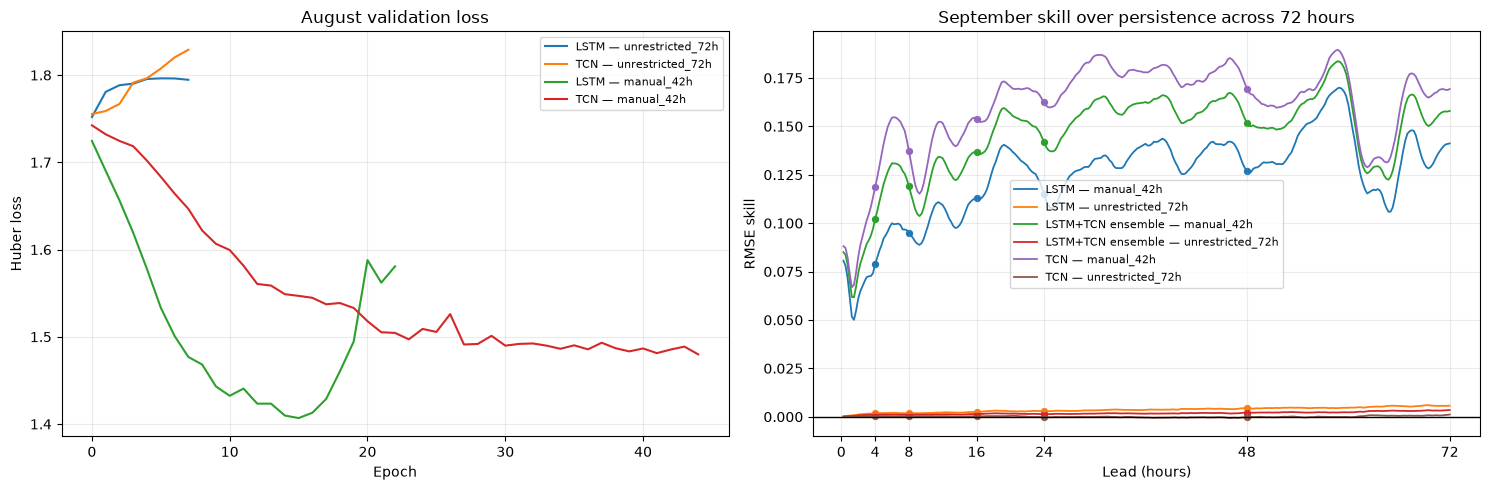

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for key, history in histories.items():
    label = f"{key[0]} — {key[1]}"
    axes[0].plot(history["val_loss"], label=label)
axes[0].set(title="August validation loss", xlabel="Epoch", ylabel="Huber loss")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=.25)

for (model_name, representation), group in horizon_results.groupby(["Model", "Representation"]):
    axes[1].plot(group["Lead hours"], group["RMSE skill"], linewidth=1.3, label=f"{model_name} — {representation}")
    marked = group[group["Lead hours"].isin(EVALUATION_HOURS)]
    axes[1].scatter(marked["Lead hours"], marked["RMSE skill"], s=18)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(title=f"September skill over persistence across {FORECAST_HOURS} hours", xlabel="Lead (hours)", ylabel="RMSE skill")
axes[1].set_xticks([0, *EVALUATION_HOURS, FORECAST_HOURS])
axes[1].legend(fontsize=8)
axes[1].grid(alpha=.25)
plt.tight_layout()
plt.show()

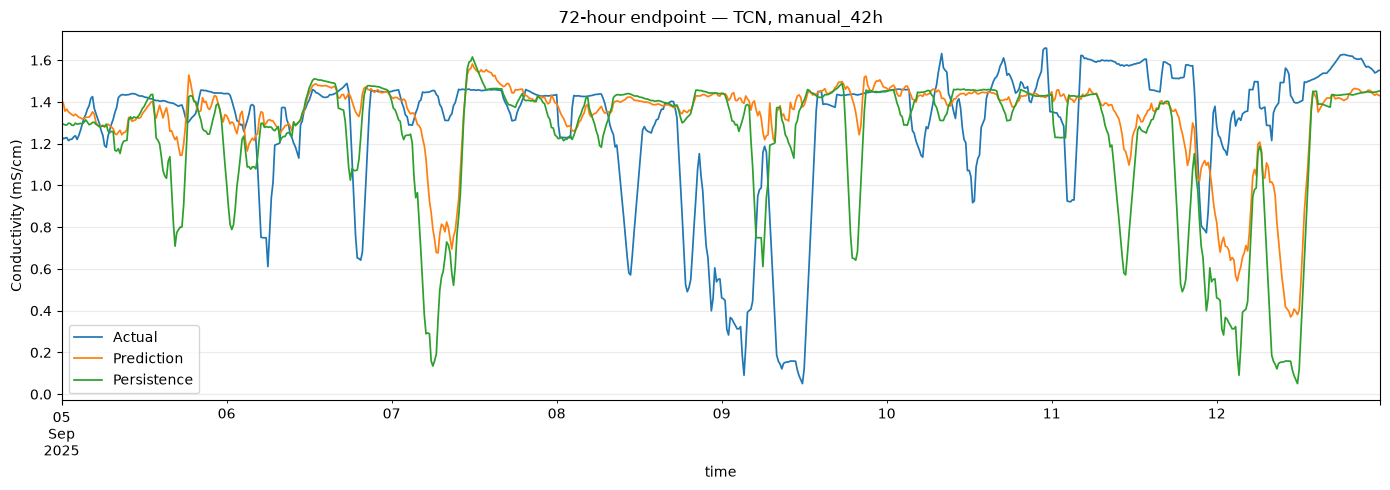

In [8]:
# Choose the illustration by August validation RMSE only.
best_row = fit_summary.iloc[0]
best_key = (best_row["Model"], best_row["Representation"])
week = predictions[best_key].loc["2025-09-05":"2025-09-12"]
ax = week.plot(figsize=(14, 5), linewidth=1.25)
ax.set_title(f"{FORECAST_HOURS}-hour endpoint — {best_key[0]}, {best_key[1]}")
ax.set_ylabel("Conductivity (mS/cm)")
ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

## 6. Reproducible conclusion

In [9]:
for representation in datasets:
    chosen = fit_summary[fit_summary["Representation"] == representation].iloc[0]
    row = results[
        (results["Model"] == chosen["Model"]) &
        (results["Representation"] == representation) &
        (results["Scope"] == "all horizons")
    ].iloc[0]
    checkpoint_rows = results[
        (results["Model"] == chosen["Model"])
        & (results["Representation"] == representation)
        & (results["Scope"].isin(checkpoint_scopes))
    ].set_index("Scope")
    checkpoint_text = ", ".join(
        f"{hours} h={checkpoint_rows.loc[f'{hours}-hour mark', 'RMSE skill']:.3f}"
        for hours in EVALUATION_HOURS
    )
    print(
        f"{representation}: August selected {chosen['Model']}; "
        f"September RMSE={row['RMSE']:.5f}, overall {FORECAST_HOURS}-hour skill={row['RMSE skill']:.3f}; "
        f"checkpoint skill: {checkpoint_text}."
    )

best_test = results[results["Scope"] == "all horizons"].sort_values("RMSE").iloc[0]
print(
    f"\nLowest September RMSE among the pre-specified neural experiments: "
    f"{best_test['Model']} with {best_test['Representation']} "
    f"({best_test['RMSE']:.5f}; skill {best_test['RMSE skill']:.3f})."
)

unrestricted_72h: August selected LSTM; September RMSE=0.33540, overall 72-hour skill=0.004; checkpoint skill: 4 h=0.002, 8 h=0.002, 16 h=0.002, 24 h=0.003, 48 h=0.004.
manual_42h: August selected TCN; September RMSE=0.28170, overall 72-hour skill=0.163; checkpoint skill: 4 h=0.119, 8 h=0.137, 16 h=0.154, 24 h=0.163, 48 h=0.169.

Lowest September RMSE among the pre-specified neural experiments: TCN with manual_42h (0.28170; skill 0.163).
